Slope (m): 4.993673878634638
Intercept (b): 0.10060355959960744

Actual Values
[ 50.  60.  75.  90. 100.]

Predicted Values
[50.03734235 60.0246901  75.00571174 89.98673338 99.97408113]

Predicted Price for 1700 sqft: 84.99305949638845


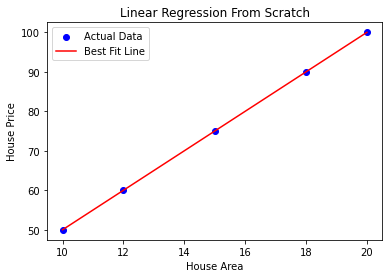

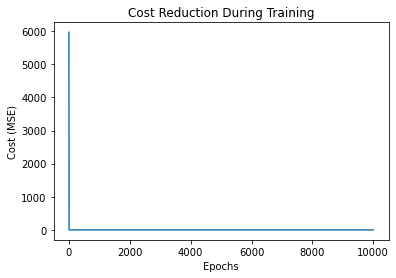

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Step 1: Create Dataset
# ----------------------------------------

X = np.array([1000, 1200, 1500, 1800, 2000], dtype=float)
y = np.array([50, 60, 75, 90, 100], dtype=float)

# ----------------------------------------
# Step 2: Initialize Parameters
# ----------------------------------------
X=X/100
m = 0
b = 0

learning_rate = 0.001
epochs = 10000

# Store cost values for plotting
cost_history = []

# ----------------------------------------
# Step 3: Gradient Descent
# ----------------------------------------

for i in range(epochs):

    # Predict values
    y_pred = m * X + b
    #print("inside loop",y_pred)
    error= y - y_pred

    # Calculate Cost (Mean Squared Error)
    cost = np.mean(error ** 2)

    cost_history.append(cost)

    # Calculate Gradients
    dm = (-2 / len(X)) * np.sum(X * error)
    db = (-2 / len(X)) * np.sum(error)

    # Update Parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

# ----------------------------------------
# Step 4: Print Final Model
# ----------------------------------------

print("Slope (m):", m)
print("Intercept (b):", b)

# ----------------------------------------
# Step 5: Final Predictions
# ----------------------------------------

final_predictions = m * X + b

print("\nActual Values")
print(y)

print("\nPredicted Values")
print(final_predictions)

# ----------------------------------------
# Step 6: Predict New Data
# ----------------------------------------

new_area = 1700
new_area=new_area/100

predicted_price = m * new_area + b

print("\nPredicted Price for 1700 sqft:", predicted_price)

# ----------------------------------------
# Step 7: Plot Best Fit Line
# ----------------------------------------

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(X, final_predictions,
         color='red',
         label='Best Fit Line')

plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("Linear Regression From Scratch")

plt.legend()

plt.show()

# ----------------------------------------
# Step 8: Plot Cost vs Epochs
# ----------------------------------------

plt.plot(cost_history)

plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Cost Reduction During Training")

plt.show()


Load the dataset.
Split the dataset into training and testing sets.
Perform feature scaling if necessary.
Initialize the model parameters (slope m and intercept b).
Set the learning rate and number of epochs.
For each epoch:
Predict the output.
Calculate the error.
Compute the cost (MSE).
Calculate the gradients.
Update the parameters using gradient descent.
After training, obtain the final regression equation.
Predict on unseen (test) data.
Evaluate the model using metrics like MSE and R² Score.
Visualize the regression line and training progress.

Final Equation
Price = 4.9939 * Area + 0.1018

Training Predictions
[99.97949477 75.01007559 50.04065641 89.9917271 ]

Actual Test Values
[60.]

Predicted Test Values
[60.02842408]

Predicted Price for 1700 sqft = 85.00

Model Evaluation
MSE : 0.0008079285278624393
R2 Score : nan


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


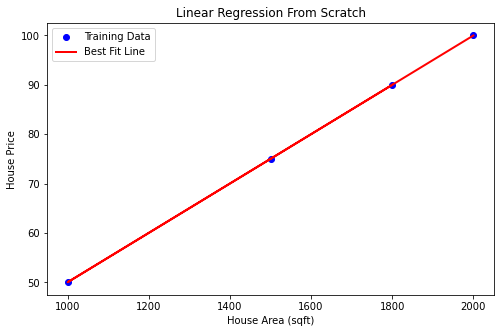

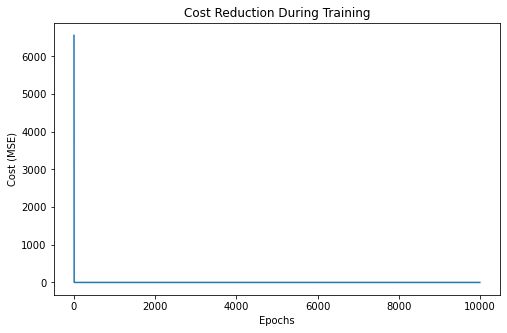

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================
# STEP 1 : Create Dataset
# =====================================================

X = np.array([1000, 1200, 1500, 1800, 2000], dtype=float)
y = np.array([50, 60, 75, 90, 100], dtype=float)

# X should be 2D for train_test_split
X = X.reshape(-1, 1)

# =====================================================
# STEP 2 : Train-Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# STEP 3 : Feature Scaling
# =====================================================

X_train = X_train / 100
X_test = X_test / 100

# =====================================================
# STEP 4 : Initialize Parameters
# =====================================================

m = 0
b = 0

learning_rate = 0.001
epochs = 10000

cost_history = []

n = len(X_train)

# Convert (n,1) -> (n,)
X_train = X_train.flatten()

# =====================================================
# STEP 5 : Gradient Descent
# =====================================================

for epoch in range(epochs):

    # Prediction
    y_pred = m * X_train + b

    # Error
    error = y_train - y_pred

    # Cost
    cost = np.mean(error ** 2)
    cost_history.append(cost)

    # Gradients
    dm = (-2 / n) * np.sum(X_train * error)
    db = (-2 / n) * np.sum(error)

    # Update Parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

# =====================================================
# STEP 6 : Final Model
# =====================================================

print("Final Equation")
print(f"Price = {m:.4f} * Area + {b:.4f}")

# =====================================================
# STEP 7 : Predictions on Training Data
# =====================================================

train_predictions = m * X_train + b

print("\nTraining Predictions")
print(train_predictions)

# =====================================================
# STEP 8 : Predictions on Test Data
# =====================================================

X_test = X_test.flatten()

test_predictions = m * X_test + b

print("\nActual Test Values")
print(y_test)

print("\nPredicted Test Values")
print(test_predictions)

# =====================================================
# STEP 9 : Predict New House
# =====================================================

new_area = 1700

new_area_scaled = new_area / 100

predicted_price = m * new_area_scaled + b

print(f"\nPredicted Price for {new_area} sqft = {predicted_price:.2f}")

# =====================================================
# STEP 10 : Model Evaluation
# =====================================================

mse = mean_squared_error(y_test, test_predictions)

r2 = r2_score(y_test, test_predictions)

print("\nModel Evaluation")
print("MSE :", mse)
print("R2 Score :", r2)

# =====================================================
# STEP 11 : Plot Best Fit Line
# =====================================================

plt.figure(figsize=(8,5))

plt.scatter(X_train * 100,
            y_train,
            color='blue',
            label='Training Data')

plt.plot(X_train * 100,
         train_predictions,
         color='red',
         linewidth=2,
         label='Best Fit Line')

plt.xlabel("House Area (sqft)")
plt.ylabel("House Price")
plt.title("Linear Regression From Scratch")
plt.legend()

plt.show()

# =====================================================
# STEP 12 : Cost vs Epochs
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Cost Reduction During Training")

plt.show()

In [8]:
# Multiple Linear Regression 
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error,r2_score

data={

"Area":[1000,1200,1500,1800,2000,2200],

"Bedrooms":[2,2,3,3,4,4],

"Age":[10,8,5,3,2,1],

"Price":[50,60,75,90,100,110]

}

df=pd.DataFrame(data)

X=df[['Area','Bedrooms','Age']]

y=df['Price']

X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Coefficients:",model.coef_)

print("Intercept:",model.intercept_)

print("MSE:",mean_squared_error(y_test,y_pred))

print("R2:",r2_score(y_test,y_pred))

new_house=[[1700,3,4]]

print("Predicted Price:",model.predict(new_house))

Coefficients: [5.00000000e-02 2.69638350e-20 7.95654147e-21]
Intercept: 0.0
MSE: 0.0
R2: 1.0
Predicted Price: [85.]


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Multiple Linear Regression

        │
        ├── Business Problem
        ├── Load Data
        ├── Explore Data
        ├── Missing Values
        ├── Duplicates
        ├── Correlation
        ├── Scatter Plots
        ├── Feature Selection
        ├── Train-Test Split
        ├── Train Model
        ├── Coefficients
        ├── Regression Equation
        ├── Prediction
        ├── R² Score
        ├── Business Interpretation
        ├── One-Hot Encoding
        └── Dummy Variable Trap

Linear Regression gives a straight line because its equation is linear (y = mx + b). Polynomial Regression gives a curve because we added polynomial features (x², x³, ...), allowing the model to fit non-linear relationships.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

data = {
    "Level":[1,2,3,4,5,6,7,8,9,10],
    "Salary":[45,50,60,80,120,180,280,420,650,1000]
}

df = pd.DataFrame(data)

X = df[['Level']]
y = df['Salary']

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

model = LinearRegression()

model.fit(X_poly, y)

y_pred = model.predict(X_poly)

plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X, y_pred, color='blue', label='Polynomial Regression')
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

new_level = poly.transform([[6.5]])

predicted_salary = model.predict(new_level)

print(predicted_salary)

Machine Learning
│
├── ✅ Introduction to Machine Learning
├── ✅ Types of ML
│     ├── Supervised Learning
│     ├── Unsupervised Learning
│     └── Reinforcement Learning
│

├── ✅ ML Pipeline
├── ✅ Train-Test Split
│

├── Regression
│     ├── ✅ Simple Linear Regression
│     ├── ✅ Cost Function
│     ├── ✅ Gradient Descent
│     ├── ✅ Linear Regression from Scratch
│     ├── ✅ Multiple Linear Regression
│     ├── ✅ One-Hot Encoding
│     ├── ✅ Dummy Variable Trap
│     └── ✅ Polynomial Regression
│

└── 🔜 Model Evaluation Metrics

Q1. When do you use Simple Linear Regression?

Answer:
When there is one independent variable and one continuous dependent variable.

Example:
Area → House Price

Q2. When do you use Multiple Linear Regression?

Answer:
When multiple independent variables influence one continuous dependent variable.
Example:
Area + Bedrooms + Age → House Price

Q3. When do you use Polynomial Regression?

Answer:
When the relationship between the input and output is non-linear (curved).

Example:
Position Level → Salary

Q4. Is Polynomial Regression a different algorithm?

Answer:
No. It uses the same LinearRegression() algorithm. We only transform the input features using PolynomialFeatures.

Q5. What is One-Hot Encoding?

Answer:
A technique to convert categorical variables into binary (0/1) columns.

Q6. What is the Dummy Variable Trap?

Answer:
It occurs when all dummy variables are included, making one dummy variable perfectly predictable from the others, causing perfect multicollinearity.

Q7. How do you avoid it?

Answer:
Drop one dummy variable (drop_first=True).

Q8. What is Multicollinearity?

Answer:
A situation where independent variables are highly correlated, making it difficult for Linear Regression to estimate stable coefficients.
